# Análisis Exploratorio de Datos (EDA)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

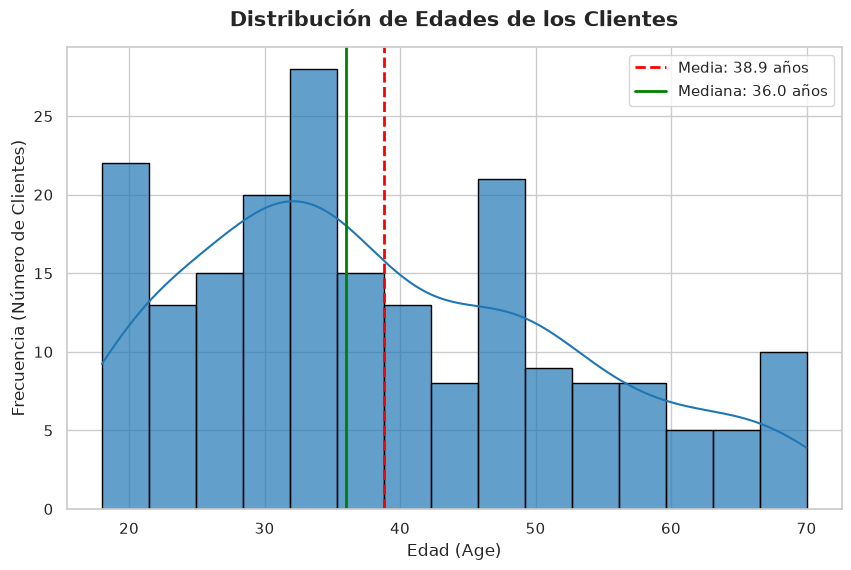

In [3]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

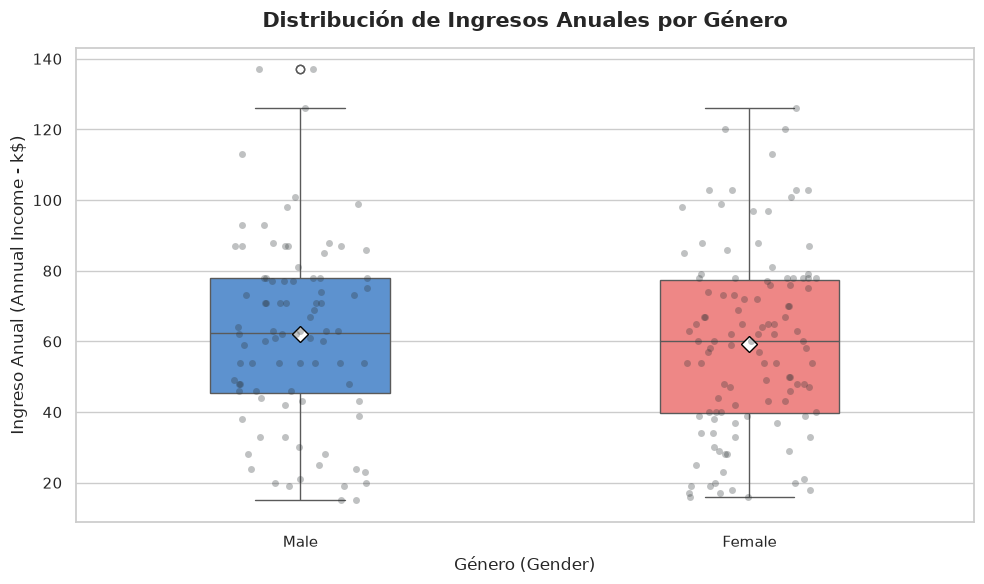

In [4]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

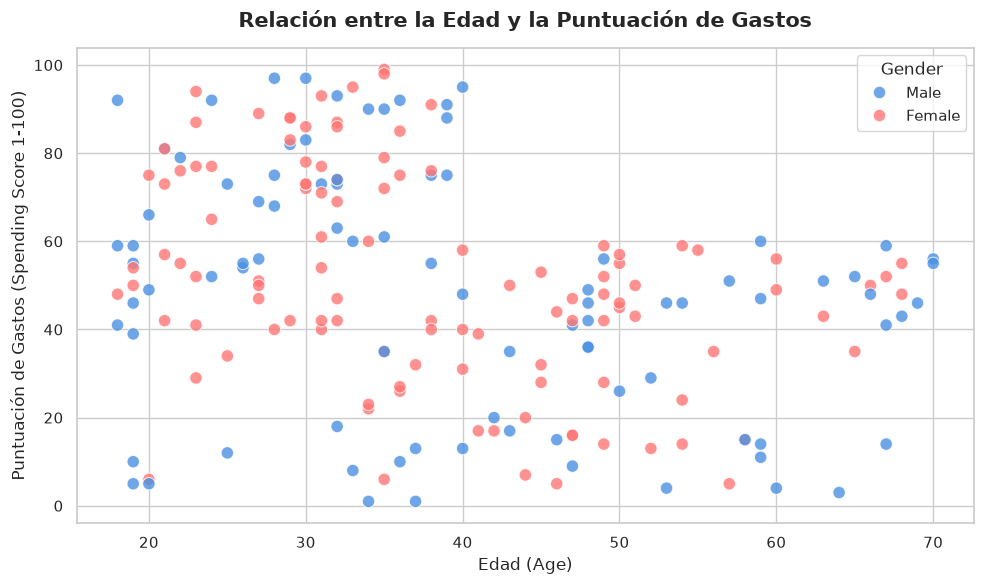

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.

# 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

Coeficiente de correlación de Pearson: 0.0099


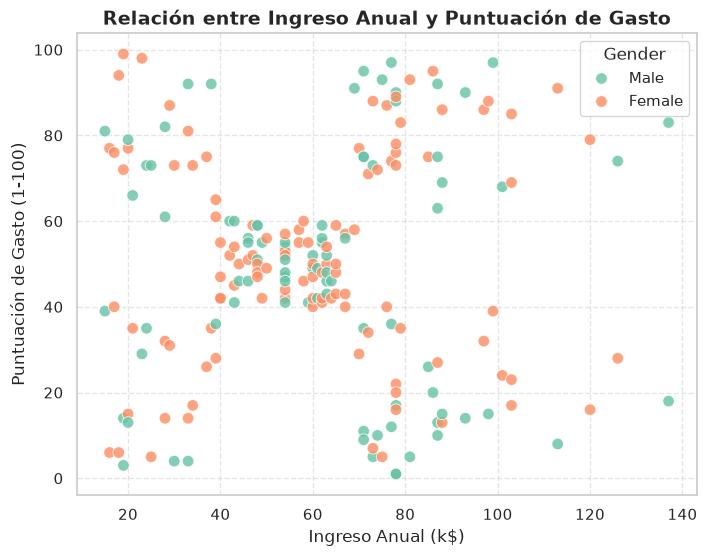

In [6]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f"Coeficiente de correlación de Pearson: {correlacion:.4f}")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Gender',  
    palette='Set2',
    s=70, 
    alpha=0.8
)

plt.title('Relación entre Ingreso Anual y Puntuación de Gasto', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso Anual (k$)', fontsize=12)
plt.ylabel('Puntuación de Gasto (1-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Conclusión e Interpretación Visual

* **Ausencia de relación lineal (Correlación = 0.0099):** 
  El coeficiente de Pearson de **0.0099** confirma que no existe una relación lineal directa entre el ingreso anual y la puntuación de gasto. Gráficamente se evidencia porque los puntos no forman una diagonal ascendente o descendente, sino que se organizan en bloques bien delimitados sobre el plano.

* **Formación clara de 5 clusters (agrupaciones naturales):**
  La distribución de los puntos revela 5 segmentos comportamentales clave dentro de la base de clientes:
  * **Centro (Gasto Moderado / Ingreso Medio):** Es el grupo más denso y concentrado. Representa a clientes con ingresos entre $40k y $70k y una puntuación de gasto equilibrada (40-60).
  * **Esquina Superior Izquierda (Bajo Ingreso / Alto Gasto):** Clientes con ingresos reducidos (menores a $40k) que registran altos niveles de gasto (60-100).
  * **Esquina Inferior Izquierda (Bajo Ingreso / Bajo Gasto):** Clientes conservadores con ingresos bajos (menores a $40k) y puntuación de gasto baja (menor a 40).
  * **Esquina Superior Derecha (Alto Ingreso / Alto Gasto):** Clientes con ingresos elevados (mayores a $70k) y alto consumo (60-100). Representa el segmento de alto valor o VIP.
  * **Esquina Inferior Derecha (Alto Ingreso / Bajo Gasto):** Clientes con ingresos altos (mayores a $70k) pero baja disposición al gasto (menor a 40).

* **Distribución por Género:**
  La variable `Gender` (puntos verdes para *Male* y naranjas para *Female*) se encuentra distribuida de manera uniforme en todos los bloques, lo que indica que el género no distorsiona la formación de los grupos.

* **Implicación para Aprendizaje No Supervisado:**
  Los datos demuestran que una regresión lineal no aporta valor analítico y confirman la idoneidad de aplicar algoritmos de agrupamiento como **K-Means** (esperando un valor óptimo de $K=5$) o **DBSCAN** para segmentar la cartera de clientes.

# 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

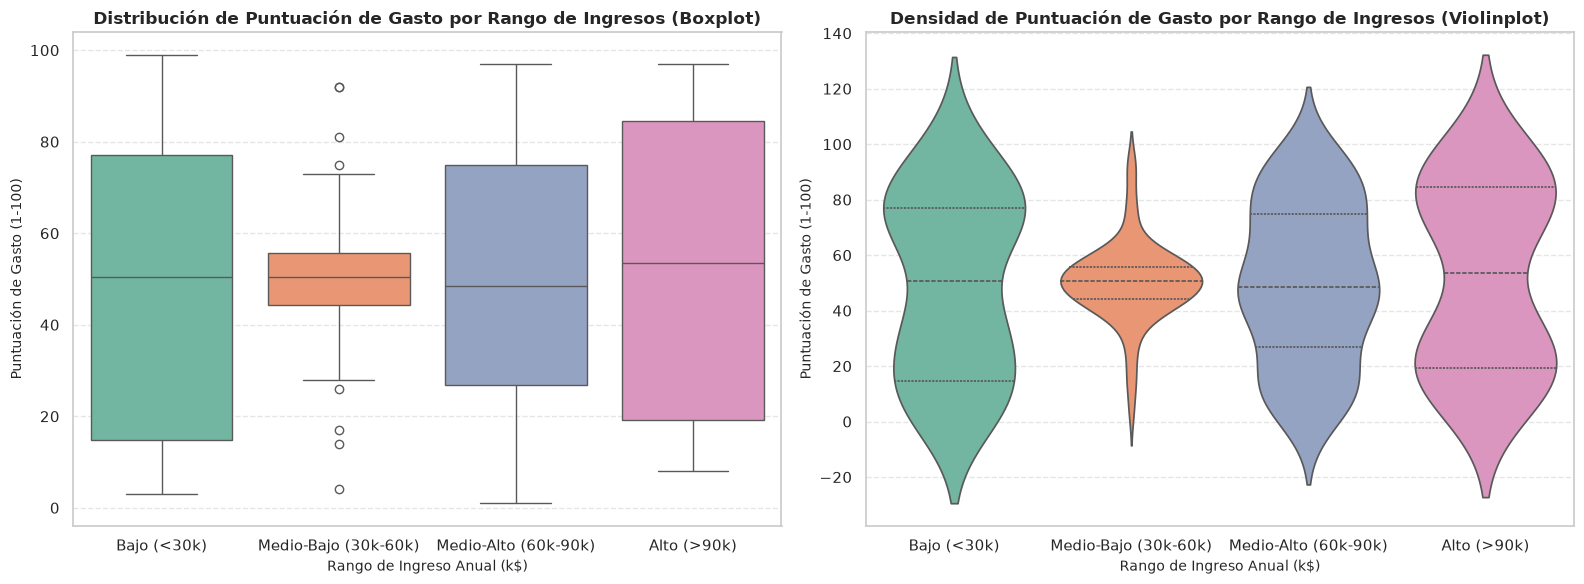

In [7]:
bins = [0, 30, 60, 90, 150]
labels = ['Bajo (<30k)', 'Medio-Bajo (30k-60k)', 'Medio-Alto (60k-90k)', 'Alto (>90k)']

df['Income_Range'] = pd.cut(df['Annual Income (k$)'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df, 
    x='Income_Range', 
    y='Spending Score (1-100)', 
    palette='Set2', 
    ax=axes[0]
)
axes[0].set_title('Distribución de Puntuación de Gasto por Rango de Ingresos (Boxplot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango de Ingreso Anual (k$)', fontsize=10)
axes[0].set_ylabel('Puntuación de Gasto (1-100)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.violinplot(
    data=df, 
    x='Income_Range', 
    y='Spending Score (1-100)', 
    palette='Set2', 
    inner='quartile', 
    ax=axes[1]
)
axes[1].set_title('Densidad de Puntuación de Gasto por Rango de Ingresos (Violinplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rango de Ingreso Anual (k$)', fontsize=10)
axes[1].set_ylabel('Puntuación de Gasto (1-100)', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Conclusión e Interpretación de los Resultados

* **Comportamiento Bimodal en los Extremos de Ingresos:**
  * Al analizar a los clientes situados en los rangos de **Ingresos Bajos (<30k)**, **Medio-Altos (60k-90k)** y **Altos (>90k)**, se observa que no existe un comportamiento uniforme hacia el centro.
  * La gráfica de violín muestra una clara estructura bimodal (forma de reloj de arena) en estos tres segmentos. Esto indica que la población de estos rangos se polariza en dos perfiles opuestos: clientes con un nivel de gasto mínimo (puntuaciones entre 10 y 20) y clientes con un nivel de gasto elevado (puntuaciones entre 70 y 90), existiendo una baja densidad de consumidores en valores intermedios.

* **Concentración Homogénea en el Rango Medio-Bajo (30k-60k):**
  * El segmento de **Ingresos Medio-Bajos (30k-60k)** exhibe un patrón de conducta sumamente controlado y predecible, a diferencia de los extremos.
  * La reducida amplitud de la caja y el ensanchamiento central del violín confirman que la gran mayoría de estos clientes mantiene puntuaciones de gasto estrictamente moderadas (concentradas entre 40 y 60 puntos). Los registros fuera de este intervalo representan observaciones atípicas.

* **Independencia entre la Mediana de Gasto y el Nivel Salarial:**
  * La mediana de la puntuación de gasto se sitúa de manera consistente alrededor de los **50 puntos** en los cuatro rangos de ingresos. 
  * Este comportamiento demuestra que la capacidad económica por sí sola no determina la propensión al gasto de los clientes dentro del establecimiento, invalidando la suposición de que a mayor ingreso corresponde automáticamente un mayor consumo.

* **Relevancia para la Segmentación mediante Aprendizaje No Supervisado:**
  * Dividir a la clientela únicamente mediante rangos de ingresos tradicionales resulta insuficiente, ya que agruparía a individuos con hábitos de consumo opuestos (ahorradores frente a compradores frecuentes) bajo una misma categoría.
  * Los hallazgos justifican plenamente el uso de algoritmos de agrupamiento como **K-Means**, el cual permite evaluar el ingreso y la puntuación de gasto de forma simultánea para identificar los segmentos reales de mercado.

# 6. ¿Cuál es la proporción de clientes por género?

Conteo por género:
 Gender
Female    112
Male       88
Name: count, dtype: int64

Porcentaje por género (%):
 Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


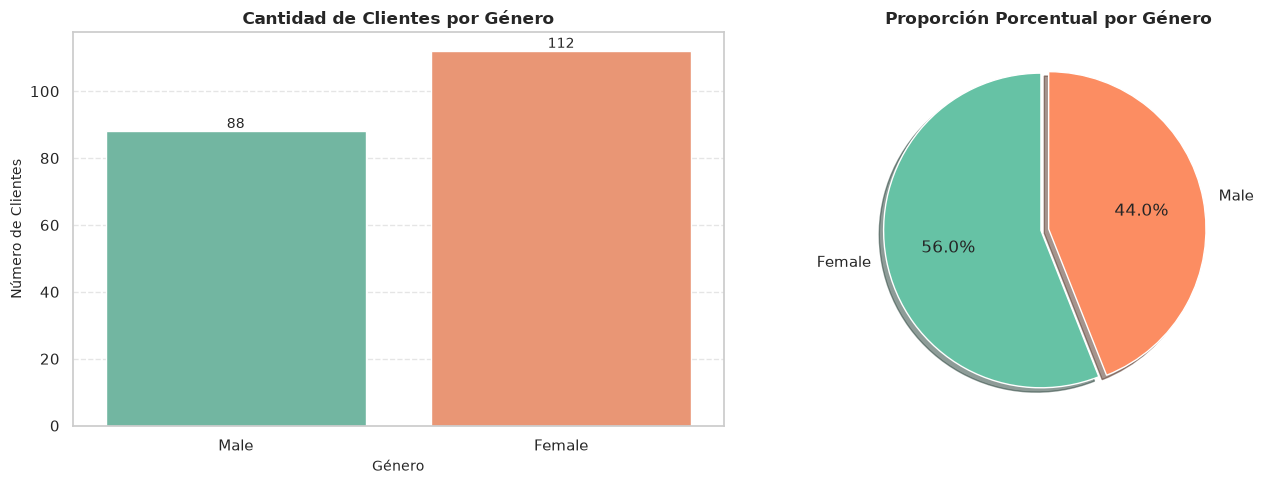

In [8]:
conteo_genero = df['Gender'].value_counts()
proporciones = df['Gender'].value_counts(normalize=True) * 100

print("Conteo por género:\n", conteo_genero)
print("\nPorcentaje por género (%):\n", proporciones.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df, 
    x='Gender', 
    palette='Set2', 
    ax=axes[0]
)
axes[0].set_title('Cantidad de Clientes por Género', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Género', fontsize=10)
axes[0].set_ylabel('Número de Clientes', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 5), 
                     textcoords='offset points', fontsize=10)

colors = sns.color_palette('Set2')[:2]
axes[1].pie(
    conteo_genero, 
    labels=conteo_genero.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    explode=(0.05, 0),
    shadow=True
)
axes[1].set_title('Proporción Porcentual por Género', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusión e Interpretación de los Resultados

* **Distribución y Mayoría Femenina:**
  * El conjunto de datos está integrado por un total de 200 registros, de los cuales **112 corresponden a mujeres (Female)** y **88 a hombres (Male)**.
  * Esto representa una proporción del **56.0% de presencia femenina** frente a un **44.0% de presencia masculina**, mostrando una leve prevalencia del público femenino en la base de clientes de RetailMax.

* **Balance Operativo del Dataset:**
  * A pesar de la ventaja numérica del grupo femenino, la diferencia entre ambos géneros es de únicamente 12 puntos porcentuales.
  * Esta distribución se considera **equilibrada y razonable** para fines de modelado, ya que no existe un sesgo o desbalance extremo que obligue a aplicar técnicas de reajuste de muestra o resampleo.

* **Implicación para el Modelo de Aprendizaje No Supervisado:**
  * La presencia balanceada de ambos géneros permite que las variables cuantitativas principales (*Annual Income* y *Spending Score*) sigan siendo las determinantes para la formación de los clusters.
  * Como observamos en el análisis de dispersión previo, el género no altera la estructura de las 5 agrupaciones naturales, por lo que el algoritmo **K-Means** podrá segmentar el mercado sin sufrir distorsiones por esta variable demográfica.

# 7. ¿Qué grupos de edad gastan más en promedio?



Puntuación de gasto promedio por grupo de edad:

              Age_Group  Spending Score (1-100)
        18-30 (Jóvenes)               61.032258
31-45 (Adultos jóvenes)               52.569444
        46-60 (Adultos)               35.102041
          60+ (Mayores)               44.176471


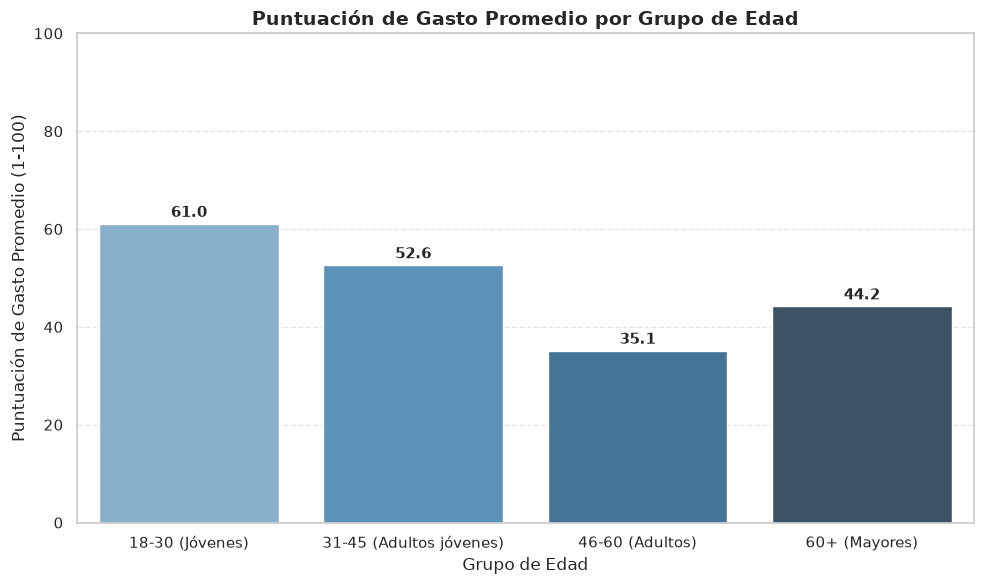

In [9]:
bins_edad = [17, 30, 45, 60, 100]
labels_edad = ['18-30 (Jóvenes)', '31-45 (Adultos jóvenes)', '46-60 (Adultos)', '60+ (Mayores)']

df['Age_Group'] = pd.cut(df['Age'], bins=bins_edad, labels=labels_edad)

gasto_promedio_edad = df.groupby('Age_Group')['Spending Score (1-100)'].mean().reset_index()

print("Puntuación de gasto promedio por grupo de edad:\n")
print(gasto_promedio_edad.to_string(index=False))

plt.figure(figsize=(10, 6))

barplot = sns.barplot(
    data=gasto_promedio_edad, 
    x='Age_Group', 
    y='Spending Score (1-100)', 
    palette='Blues_d'
)

plt.title('Puntuación de Gasto Promedio por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Puntuación de Gasto Promedio (1-100)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in barplot.patches:
    barplot.annotate(
        f'{p.get_height():.1f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 8), 
        textcoords='offset points', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Conclusión e Interpretación de los Resultados

* **Liderazgo del Rango Joven (18-30 años):**
  * El grupo de **18-30 años (Jóvenes)** registra la puntuación de gasto promedio más alta de la base de datos, alcanzando **61.0 puntos**.
  * Este resultado demuestra que los clientes más jóvenes son el motor de mayor inclinación al consumo dentro de RetailMax.

* **Tendencia Descendente con la Edad:**
  * Se observa una clara relación inversa entre la edad y la disposición al gasto en los primeros tres rangos: el promedio disminuye a **52.6 puntos** en el segmento de **31-45 años (Adultos jóvenes)** y cae a su nivel mínimo de **35.1 puntos** en el grupo de **46-60 años (Adultos)**.
  * No obstante, el grupo de **60+ años (Mayores)** experimenta una ligera recuperación situándose en **44.2 puntos**, aunque manteniéndose por debajo de los niveles de los grupos más jóvenes.

* **Relevancia para la Segmentación y Estrategia:**
  * La variable `Age` refleja patrones de comportamiento bien marcados según la etapa de vida del cliente.
  * Para el modelo de **Aprendizaje No Supervisado**, incorporar la edad junto al ingreso anual y la puntuación de gasto aportará dimensiones cruciales para caracterizar mejor los clusters (por ejemplo, diferenciando a los compradores jóvenes de alto gasto frente a los compradores maduros más conservadores).

# 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

Coeficiente de correlación entre Edad e Ingreso: -0.0124


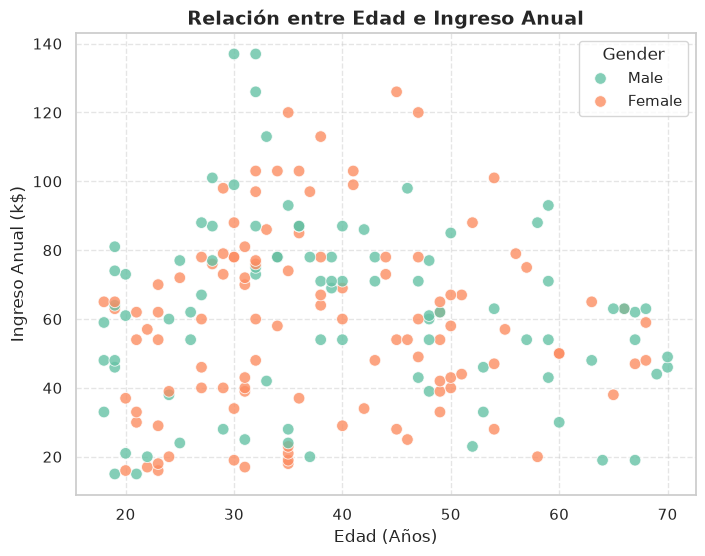

In [10]:
correlacion_edad_ingreso = df['Age'].corr(df['Annual Income (k$)'])
print(f"Coeficiente de correlación entre Edad e Ingreso: {correlacion_edad_ingreso:.4f}")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Annual Income (k$)', 
    hue='Gender', 
    palette='Set2', 
    s=70, 
    alpha=0.8
)

plt.title('Relación entre Edad e Ingreso Anual', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Ingreso Anual (k$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Conclusión e Interpretación de los Resultados

* **Ausencia de Correlación Lineal (-0.0124):**
  * El coeficiente de Pearson resulta prácticamente nulo (**-0.0124**), lo que demuestra que no existe una tendencia lineal entre la edad y los ingresos de los clientes.
  * Tener más edad no garantiza percibir mayores ingresos dentro de este conjunto de datos; los sueldos altos y bajos se distribuyen a lo largo de todas las edades.

* **Distribución de Ingresos Altos en Adultos Jóvenes:**
  * Aunque los datos están dispersos, se aprecia una ligera concentración de los ingresos más elevados (superiores a $100k) en el rango de los **30 a 50 años**.
  * Los clientes menores de 25 años y mayores de 60 años tienden a registrar ingresos más moderados o bajos, concentrándose mayoritariamente por debajo de los $80k.

* **Distribución Homogénea por Género:**
  * La separación por género (*Male* en verde y *Female* en naranja) no revela diferencias marcadas en el nivel de ingresos para un mismo rango de edad, manteniendo una dispersión pareja en todo el plano.

* **Implicación para el Modelo de Aprendizaje No Supervisado:**
  * La independencia entre la edad y el ingreso confirma que ambas variables aportan información ortogonal (no redundante) al modelo.
  * Al alimentar algoritmos como **K-Means**, contar con variables no correlacionadas ayuda a que cada dimensión contribuya de forma limpia en la construcción de los clusters sin distorsionar las distancias euclidianas.

# 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?



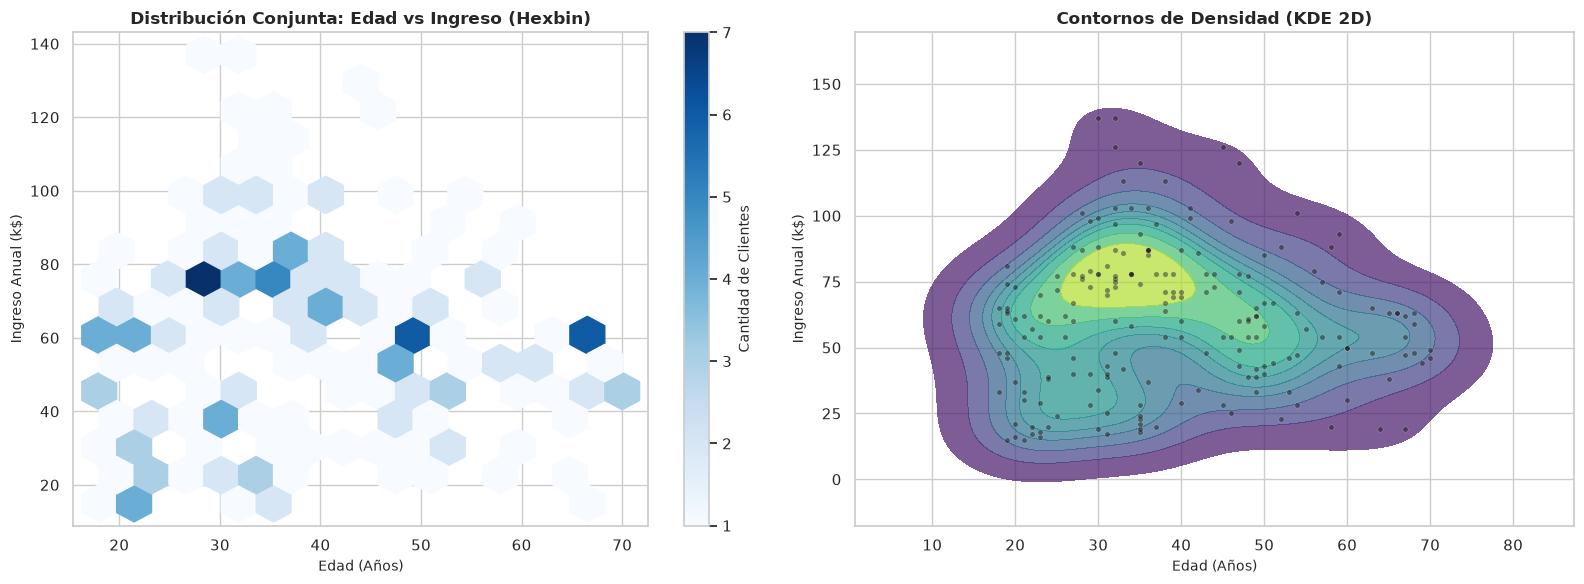

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hb = axes[0].hexbin(
    df['Age'], 
    df['Annual Income (k$)'], 
    gridsize=15, 
    cmap='Blues', 
    mincnt=1
)
axes[0].set_title('Distribución Conjunta: Edad vs Ingreso (Hexbin)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad (Años)', fontsize=10)
axes[0].set_ylabel('Ingreso Anual (k$)', fontsize=10)
cb1 = fig.colorbar(hb, ax=axes[0])
cb1.set_label('Cantidad de Clientes', fontsize=10)

sns.kdeplot(
    data=df, 
    x='Age', 
    y='Annual Income (k$)', 
    cmap='viridis', 
    fill=True, 
    thresh=0.05, 
    levels=10, 
    ax=axes[1],
    alpha=0.7
)

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Annual Income (k$)', 
    color='black', 
    s=15, 
    alpha=0.4, 
    ax=axes[1]
)
axes[1].set_title('Contornos de Densidad (KDE 2D)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad (Años)', fontsize=10)
axes[1].set_ylabel('Ingreso Anual (k$)', fontsize=10)

plt.tight_layout()
plt.show()

### Conclusión e Interpretación de los Resultados

* **Zona de Mayor Concentración (Núcleo Principal):**
  * En el mapa de contornos de densidad (KDE 2D) se observa claramente una zona caliente (área verde amarillenta) situada entre los **30 y 40 años** de edad, con un nivel de ingresos entre **$60k y $80k**.
  * El gráfico de hexágonos (*Hexbin*) respalda este hallazgo mostrando su celda de azul más intenso (con un pico de hasta 7 clientes) exactamente cerca de los **30 años y $75k** de ingreso anual.

* **Distribución de la Masa de Clientes:**
  * **Jóvenes (18–30 años):** Muestran una dispersión vertical amplia, con presencia constante en rangos de ingreso bajo ($15k–$40k) y medio-alto ($60k–$80k).
  * **Adultos (30–50 años):** Concentran la mayor variabilidad salarial de la muestra, abarcando desde los ingresos más bajos hasta los picos máximos de la tienda ($120k–$140k).
  * **Mayores (>50 años):** Tienen una densidad progresivamente menor, distribuyéndose casi exclusivamente en rangos de ingresos moderados e intermedios ($40k–$70k).

* **Utilidad para el Modelo de Aprendizaje No Supervisado:**
  * La visualización conjunta confirma que los datos no forman grupos aislados basados únicamente en `Age` e `Income`, sino que existe una masa central uniforme combinada con regiones periféricas más dispersas.
  * Esto reafirma la importancia de incorporar la variable `Spending Score` al modelo de **K-Means**, ya que será la dimensión decisiva para dividir eficazmente tanto el núcleo denso como las zonas periféricas en clusters comportamentales significativos.

# 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

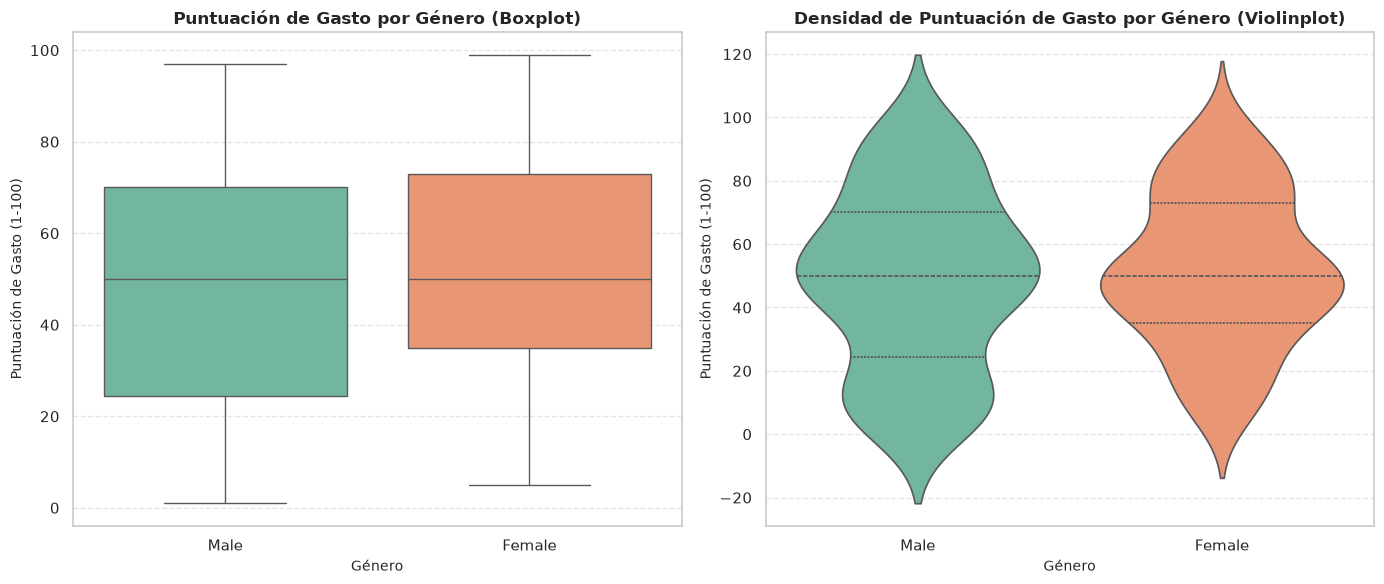

Estadísticos de Spending Score por Género:

        count   mean    std  min   25%   50%   75%   max
Gender                                                  
Female  112.0  51.53  24.11  5.0  35.0  50.0  73.0  99.0
Male     88.0  48.51  27.90  1.0  24.5  50.0  70.0  97.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df, 
    x='Gender', 
    y='Spending Score (1-100)', 
    palette='Set2', 
    ax=axes[0]
)
axes[0].set_title('Puntuación de Gasto por Género (Boxplot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Género', fontsize=10)
axes[0].set_ylabel('Puntuación de Gasto (1-100)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.violinplot(
    data=df, 
    x='Gender', 
    y='Spending Score (1-100)', 
    palette='Set2', 
    inner='quartile', 
    ax=axes[1]
)
axes[1].set_title('Densidad de Puntuación de Gasto por Género (Violinplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género', fontsize=10)
axes[1].set_ylabel('Puntuación de Gasto (1-100)', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Estadísticos de Spending Score por Género:\n")
print(df.groupby('Gender')['Spending Score (1-100)'].describe().round(2))

### Conclusión e Interpretación de los Resultados

* **Similitud en la Mediana del Gasto:**
  * La mediana de la puntuación de gasto es prácticamente idéntica para ambos géneros, situándose en **50 puntos** tanto en hombres (*Male*) como en mujeres (*Female*).
  * Esto indica que, en términos generales, el comportamiento de gasto central de un cliente no depende de su género.

* **Diferencias en la Dispersión y Rangos Intercuartílicos:**
  * **Hombres (Male):** Presentan una dispersión ligeramente mayor en la parte inferior del rango. La caja se extiende más hacia abajo (cuartil inferior alrededor de los 25 puntos), mostrando un abultamiento relevante en puntuaciones bajas (entre 10 y 20).
  * **Mujeres (Female):** Tienen un rango intercuartílico un poco más compacto y concentrado en la zona media-alta (cuartil inferior cerca de los 35 puntos y cuartil superior en los 73 puntos), lo que sugiere un gasto moderado a alto algo más constante.

* **Simetría en los Extremos Máximos:**
  * Ambos grupos alcanzan puntuaciones máximas muy similares, rozando los **99-100 puntos**, por lo que existe una proporción equitativa de compradores de alto valor tanto masculinos como femeninos.

* **Implicación para el Modelo de Aprendizaje No Supervisado:**
  * Las diferencias de gasto por género son sutiles y no generan clusters aislados por sí solas.
  * Se confirma nuevamente que el género actúa como una variable de soporte, dejando el peso de la segmentación en `Annual Income` y `Spending Score` para el algoritmo **K-Means**.